<a href="https://colab.research.google.com/github/Saurabh-Kurhade-Patil/Data-Science-Notebooks/blob/main/quora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('train.csv')

In [22]:
df = df.sample(30000)

In [23]:
df.shape

(30000, 6)

In [24]:
df.sample(10)

,id,qid1,qid2,question1,question2,is_duplicate
19876,19876,37551,37552,Suggest me a topic for maths project?,What rank can I expect with 220 marks in JEE M...,0
14725,14725,28185,28186,How do I gain self-confidence?,When do you truly gain self-confidence?,0
26113,26113,48640,48641,What are some ways to expand my knowledge and ...,What are the best ways to expand your knowledge?,1
12623,12623,24307,24308,Where can I buy first copy shoes in mumbai?,"Where, in Bangalore one can find first copy sh...",0
23035,23035,43185,43186,How can I get perfect idea about best golf carts?,Is it hard to get a job in US after MIS withou...,0
9812,9812,19053,19054,Why would someone become a porn star?,Why do people become actors in the porn industry?,1
26711,26711,49673,49674,Can we expect Conjuring 3?,The Conjuring: Why is it such a big hit?,0
16331,16331,31139,31140,How do I prepare for the CELTA writing task?,Do we have enough medicine and technology to s...,0
7557,7557,9739,14761,How do I get rid of scalp acne?,How did you cure your acne?,1
59,59,119,120,What are the best ways to learn French?,How do I learn french genders?,0


In [25]:
df.isna().sum()

,0
id,0
qid1,0
qid2,0
question1,0
question2,0
is_duplicate,0


In [26]:
df.dropna(inplace=True)

In [27]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='is_duplicate'>

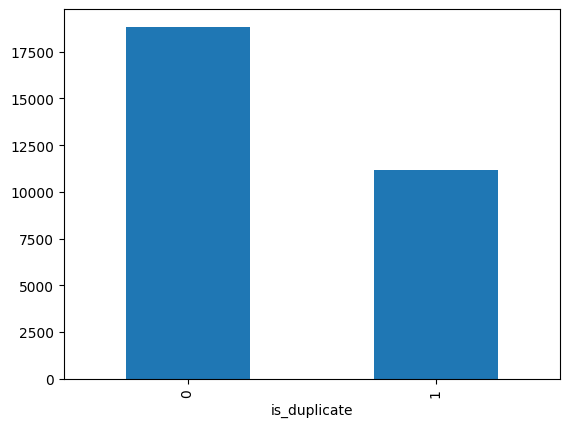

In [28]:
df['is_duplicate'].value_counts().plot(kind='bar')

In [29]:
df['is_duplicate'].value_counts()/df['is_duplicate'].count()*100

,count
is_duplicate,
0,62.81
1,37.19


In [30]:
qid = pd.Series(df['qid1'].tolist()+df['qid2'].tolist())
print('Unique number of questions :',np.unique(qid).shape[0], 'which consists of :',np.unique(qid).shape[0]/len(qid)*100,'%')

Unique number of questions : 55456 which consists of : 92.42666666666666 %


In [31]:
x=qid.value_counts()>1
print('Number of questions getting repeated',x[x].shape[0])

Number of questions getting repeated 3380


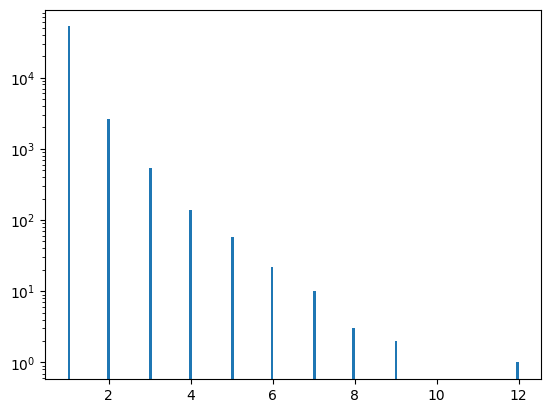

In [32]:
plt.hist(qid.value_counts().values, bins=160)
plt.yscale('log')
plt.show()

Without any EDA lets findout how the model is understanding the text

In [33]:
from sklearn.feature_extraction.text import CountVectorizer

In [34]:
df_questions = df[['question1', 'question2']]

In [35]:
questions = list(df_questions['question1']) + list(df_questions['question2'])

In [36]:
cv =  CountVectorizer(max_features=3000)

q1, q2 = np.vsplit(cv.fit_transform(questions).toarray(),2)

In [37]:
q1

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [38]:
temp_df1 = pd.DataFrame(q1, index= df_questions.index)
temp_df2 = pd.DataFrame(q2, index= df_questions.index)
temp_df = pd.concat([temp_df1, temp_df2], axis=1)
temp_df.shape

(30000, 6000)

In [39]:
temp_df

,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
25024,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9835,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
21360,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7381,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14407,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1159,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7140,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12517,0,0,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
29673,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [40]:
temp_df['is_duplicate'] = df['is_duplicate']

In [41]:
temp_df

,0,1,2,3,4,5,6,7,8,9,...,2991,2992,2993,2994,2995,2996,2997,2998,2999,is_duplicate
25024,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
9835,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
21360,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
7381,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14407,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1159,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7140,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
12517,0,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
29673,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [42]:
from sklearn.model_selection import train_test_split

In [43]:
X_train, X_test, y_train, y_test = train_test_split(temp_df.iloc[:,0:-1].values, temp_df.iloc[:,-1].values, test_size=0.2, random_state=42)

In [44]:
from sklearn.ensemble import RandomForestClassifier

In [45]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

RandomForestClassifier()

In [46]:
y_pred = rf.predict(X_test)

In [47]:
from sklearn.metrics import accuracy_score

In [48]:
accuracy_score(y_test, y_pred)

0.7451666666666666